In [1]:
import numpy as np

import modules.models as models
import modules.tools as tools

from numpy import cos, sin, pi, exp, sqrt, sinh, tanh
import scipy.integrate as integrate

from scipy.special import erf, erfi

import scipy.sparse.linalg as sla

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os
import pickle
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/Zenodo


In [3]:
from functools import partial

In [4]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [5]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

### Define Analytical expressions

In [6]:
def phi1(z, qx, Qx, R, L, t2, t=1., d=1.):
    
    lamb = -qx*sin(Qx)/t2
    sigma = sqrt(R*t2/cos(Qx))    
    chi_plus = (L + 2*lamb* sigma**2)/(2*sigma) 
    chi_minus = (L - 2*lamb* sigma**2)/(2*sigma) 
       
    erf_chi_plus = erf(chi_plus)
    erf_chi_minus = erf(chi_minus)

    C = erf_chi_plus + erf_chi_minus
    
    if C != 0.:
        return 1/sqrt(C) * (4/pi/sigma**2)**0.25 * exp(-(z - lamb* sigma**2)**2 /2/sigma**2) 
    else:
        return (phi1_0(z, qx=qx, Qx=Qx, L=L, t2=t2, t=t, d=d)
                              * exp(-(z**2 - L**2/4)/2/sigma**2))

In [7]:
def phi1_0(z, qx, Qx, L, t2, t=1., d=1.):

    lamb = -qx*sin(Qx)/t2 

    C = lamb/sinh(lamb*L)
    
    return sqrt(C) * exp(lamb*z)  

In [8]:
def phi2(z, qx, Qx, R, L, t2, t=1., d=1.):
    
    lamb = -qx*sin(Qx)/t2
    sigma = sqrt(R*t2/cos(Qx))
    
    chi_plus = (L + 2*lamb* sigma**2)/(2*sigma) 
    chi_minus = (L - 2*lamb* sigma**2)/(2*sigma) 
    
    if lamb*sigma**2 >= L/2:
        if abs(chi_plus)<24. and abs(chi_minus)<24.:
            D = erfi(chi_plus) + erfi(chi_minus)
            return 1/sqrt(D) * (4/pi/sigma**2)**0.25 * exp((z - lamb* sigma**2)**2 /2/sigma**2)  
        else:
            return (phi2_0(z, qx=qx, Qx=Qx, L=L, t2=t2, t=t, d=d)
                          * exp((z**2 - L**2/4)/2/sigma**2))
    else:
        if lamb*sigma**2 > -L/2:
            Dtilde = sqrt(2*exp((lamb*sigma)**2)/sigma/(2*chi_minus + sqrt(pi)*erfi(chi_plus)))
            temp_func = np.piecewise(z, [z < lamb*sigma**2, z >= lamb*sigma**2],
                               [lambda z: Dtilde* exp(-lamb*z) * exp(z**2/2/sigma**2),
                                lambda z: Dtilde* exp(-(lamb*sigma)**2 /2)])
            return temp_func
        else:
            return 1./sqrt(L) * exp(z-z)
        

In [9]:
def phi2_0(z, qx, Qx, L, t2, t=1., d=1.):

    lamb = -qx*sin(Qx)/t2  

    C = lamb/sinh(lamb*L)
    
    return sqrt(C) * exp(-lamb*z)  

In [10]:
def H_eff(qx, Qx, R, L, t2, t=1., d=1.):
    
    lamb = -qx*sin(Qx)/t2
    sigma = sqrt(R*t2/cos(Qx))
    chi_plus = (L + 2*lamb* sigma**2)/(2*sigma) 
    chi_minus = (L - 2*lamb* sigma**2)/(2*sigma) 
    
    if lamb*sigma**2 >= L/2:
        fac_erf = erf(chi_plus) + erf(chi_minus)    
        if np.isposinf(abs(erfi(chi_plus))) or np.isposinf(abs(erfi(chi_minus))) :
            H12 = 0.0
        else:
            fac_erfi = erfi(chi_plus) + erfi(chi_minus)  
            if fac_erf == 0.0:
                H12 = 0.0
            else:
                H12 = 1./sqrt(pi) * 2*L/sigma / sqrt(fac_erfi*fac_erf)                                      
    else:
        if lamb*sigma**2 >= -L/2:
            fac_erf = erf(chi_plus) + erf(chi_minus)
            if np.isposinf(abs(erfi(chi_plus))) or np.isposinf(abs(erf(chi_minus))):
                H12 = 0.0
            else:
                if fac_erf == 0.0:
                    H12 = 0.0
                else:
                    H12 = 1./sqrt(pi) * ((2*chi_plus + sqrt(2*pi)*erf(chi_minus/sqrt(2)))/
                                         sqrt(fac_erf*(erfi(chi_plus) + 2*chi_minus/sqrt(pi))))
        else:
            fac_erf = erf(chi_plus) + erf(chi_minus)
            if abs(chi_plus)<24. and abs(chi_minus)<24. and fac_erf != 0.:
                fac_erf_2 = erf(chi_plus/sqrt(2)) + erf(chi_minus/sqrt(2))
                H12 = (pi*sigma**2/L**2)**(1/4) * fac_erf_2/sqrt(fac_erf) 
            else:
                H12 = sqrt(tanh(lamb*L/2)/(lamb*L/2)) #not very accurate

    return np.array([[0., H12],[H12, 0.]])

In [11]:
def effective_phis(qs, evecs, phi1, phi2, overlap):

    states_plus = list()
    states_minus = list()

    #params = dict(Qx=Qx, R=R, L=L, t2=t2)

    for i,q in enumerate(qs):

        v00 = evecs[i,0,0]
        v01 = evecs[i,0,1]
        v10 = evecs[i,1,0]
        v11 = evecs[i,1,1]

        states_plus.append(lambda z, q=q, i=i: ((phi1(z,q)*v00 + phi2(z,q)*v01)/
                                           sqrt(1 + 2*np.real(v00*v01)*overlap(q))))
        
        states_minus.append(lambda z, q=q, i=i: ((phi1(z,q)*v10 + phi2(z,q)*v11)/
                                            sqrt(1 + 2*np.real(v10*v11)*overlap(q))))
    
    return states_plus, states_minus

In [12]:
L=1000
R = 8*L
t1 = 0.25
Qx = np.arccos((2.-t1)/2.)
t2 = 0.8

### Analytical solutions

#### (a) wave functions

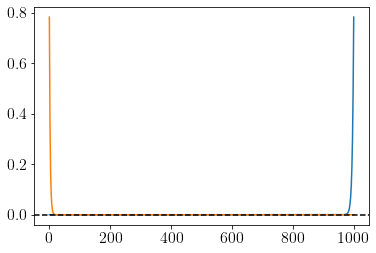

In [13]:
qx = -Qx

zs = np.linspace(-L/2, L/2, 1000)
plt.plot(phi1(zs, qx, Qx, R, L, t2))
plt.plot(phi2(zs, qx, Qx, R, L, t2))
plt.axhline(0.0, c='k', ls='--')

#plt.plot(zs, phi2_0(zs, qx, Qx, L, t2))
#plt.ylim(0.0,0.05)

In [14]:
integrate.quad(lambda z: phi2(z, qx=qx, Qx=Qx, R=R, L=L, t2=t2)**2, -L/2, L/2)

(0.8177085446211915, 1.0993907069332617e-12)

#### (b) effective Hamiltonian

In [15]:
n=201
qxs = np.linspace(-Qx,Qx+0.2,n)
energies_an = np.zeros((n,2))
evecs_an = np.zeros((n,2,2), dtype=complex)
for i,q in enumerate(qxs):
    energies_an[i,:], evecs_an[i,:,:] = np.linalg.eigh(H_eff(q, Qx, R, L, t2))

In [16]:
H_eff(-0.6, Qx, R, L, t2)

array([[0., 0.],
       [0., 0.]])

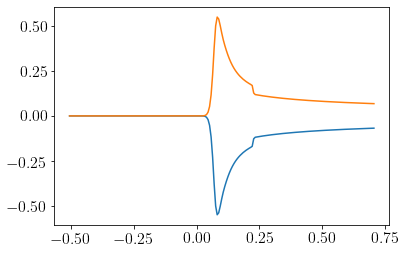

In [17]:
plt.plot(qxs,energies_an)
#plt.ylim(-0.001,0.001)

In [18]:
params = dict(Qx=Qx, R=R, L=L, t2=t2)
overlap = lambda qx: H_eff(qx, **params)[0,1]

states_plus, states_minus = effective_phis(qxs, evecs_an, partial(phi1,**params), 
                                           partial(phi2,**params), overlap)

-0.5053605102841573


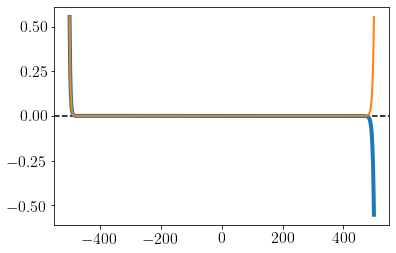

In [19]:
i=0
print(qxs[i])
plt.axhline(0.0, ls='--', c='k')
plt.plot(zs, np.real(states_plus[i](zs)), lw=4)
plt.plot(zs, np.real(states_minus[i](zs)), lw=2)
#plt.plot(zs, np.imag(states_plus[i](zs)), lw=4)
#plt.plot(zs, np.imag(states_minus[i](zs)), lw=2)

In [20]:
integrate.quad(lambda z: abs(states_plus[i](z))**2, -L/2, L/2)

(1.0520143236449042, 1.6233560823410605e-10)

In [21]:
integrate.quad(lambda z: abs(states_minus[i](z))**2, -L/2, L/2)

(1.0520143236449042, 1.6233560823410605e-10)

In [22]:
evecs_an[i,:,:]

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

### Compare numerics to analytics

In [132]:
Lz=1000 #1000
R = 8000 #10000
t1 = 0.25 #0.5**2 #0.5
t2 = 0.8 # 1.0

Nk = 201

In [133]:
print(np.arccos((2.-t1)/2.))

0.5053605102841573


In [134]:
Qx = np.arccos((2.-t1)/2.) #sqrt(t1) 
kxs = np.linspace(0.0,Qx+0.2,Nk)
ky = 0.

q_critical = L/(2*sin(Qx)/t2*R*t2/cos(Qx))
print(q_critical)
print(Qx-q_critical)

0.11296201426438299
0.3923984960197743


In [102]:
# numerical solutions
n=8

energies_nu = np.zeros((Nk,n))
evecs_nu = np.zeros((Nk,2*Lz,n), dtype='complex')

for i,kx in tqdm(list(enumerate(kxs))):
    energies_nu[i,:], evecs_nu[i,:,:] = sla.eigsh(models.H_strain(kx, ky, Lz, R, t1, t2),
                                                 k=n, sigma=1e-10, which='LM')

for i in range(Nk):
    sorted_indices = np.argsort(energies_nu[i,:])
    energies_nu[i,:] = energies_nu[i,sorted_indices]
    evecs_nu[i,:,:] = np.transpose(evecs_nu[i,:,sorted_indices])

In [135]:
# analytical solutions
lamb = 0.02
params = dict(Qx=Qx, R=R, L=Lz, t2=t2)

energies_an = np.zeros((Nk,2))
evecs_temp = np.zeros((Nk,2,2), dtype=complex)
for i,kx in enumerate(kxs):
    energies_an[i,:], evecs_temp[i,:,:] = np.linalg.eigh(lamb*H_eff(kx-Qx, **params))

In [136]:
overlap = lambda qx: H_eff(qx, **params)[0,1]

evecs_an = effective_phis(kxs-Qx, evecs_temp, partial(phi1,**params), 
                                           partial(phi2,**params), overlap)

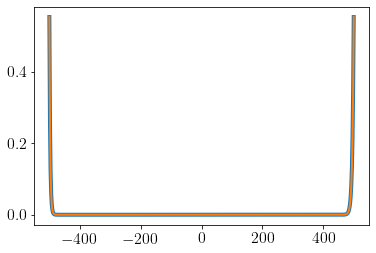

In [137]:
zs = np.linspace(-Lz/2, Lz/2, Lz)
plt.plot(zs, np.abs(evecs_an[0][0](zs)), lw=4)
plt.plot(zs, np.abs(evecs_an[1][0](zs)), lw=2)

In [138]:
kxs_neg = -kxs[::-1]
energies_nu_neg = energies_nu[::-1,:]
energies_an_neg = energies_an[::-1,:]

(-0.7, 0.7)

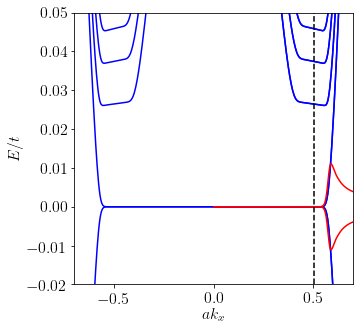

In [139]:
# plot energies
plt.figure(figsize=(5,5))
plt.plot(kxs, energies_nu[:,0], 'b-', label='tight-binding')
plt.plot(kxs, energies_nu, 'b-')
plt.plot(kxs_neg, energies_nu_neg, 'b-', label='tight-binding')
plt.plot(kxs, energies_nu, 'b-')
plt.plot(kxs, energies_an[:,0], 'r', label='analytics')
plt.plot(kxs, energies_an[:,1], 'r')
plt.axvline(Qx,ls='--',c='k', label='nodal line')
#plt.plot(0.54,-0.0008,'go', label='momenta in (b)') 
#plt.plot(0.54,0.0008,'go') 
#plt.plot(0.505,0.0,'go') 
#plt.plot(0.46,0.0,'go')
#plt.plot(0.42,0.0,'go')
#plt.plot(0.35,0.0,'go')
#plt.plot(0.0,0.0,'go') 
plt.xlabel('$ak_x$')
plt.ylabel('$E/t$')
plt.ylim(-0.02,0.05)
plt.xlim(-0.7,0.7)


In [140]:
evecs_zeros = evecs_nu[:,:,3:5]

0.0


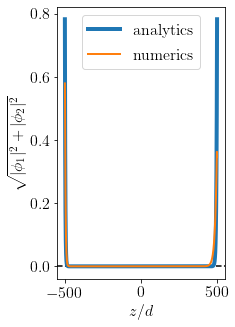

In [141]:
#plot states
i = 0
print(kxs[i])

zs = np.linspace(-Lz/2, Lz/2, Lz)
densities1 = tools.density(evecs_zeros[i,:,0], 2)
densities2 = tools.density(evecs_zeros[i,:,1], 2)

evecs_an_density = np.zeros((Nk,Lz))

for j in range(Nk):
    evecs_an_density[j,:] = np.abs(evecs_an[0][j](zs))**2 + np.abs(evecs_an[1][j](zs))**2

plt.figure(figsize=(3,5))
plt.axhline(0.0, ls='--', c='k')
plt.plot(zs, sqrt(evecs_an_density[i,:]), lw=4, label='analytics')                                                                
plt.plot(zs, sqrt(densities1+densities2), lw=2, label='numerics');
plt.xlabel('$z/d$')
plt.ylabel('$\sqrt{|\phi_1|^2 + |\phi_2|^2}$')
plt.legend(loc=9)
#plt.savefig('density_035.pdf')

#### Save to file for figures

In [143]:
params = dict(Lz=Lz, R=R, t1=t1, t2=t2, Nk=Nk, Qx=Qx, lamb=lamb, 
              Q_bot=Q_bot_R, Q_top=Q_top_R)

In [144]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'effective_hamiltonian'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(kxs, fp)
pickle.dump(energies_nu, fp)
pickle.dump(evecs_zeros, fp)
pickle.dump(energies_an, fp)
pickle.dump(evecs_an_density, fp)
#fp.close()

## Critical nodal line radius

In [23]:
t1 = 0.25 #0.5**2 #0.5
t2 = 0.8 # 1.0
R=8000
L=1000

In [24]:
Qx=np.arccos((2.-t1)/2.)

In [25]:
Q_top_an = lambda R,L: Qx - (L*cos(Qx)/2/R/sin(Qx))
Q_bot_an = lambda R,L: Qx + (L*cos(Qx)/2/R/sin(Qx))

In [26]:
Q_bot = lambda R,L: np.arccos((2-t1)/(2*(1+L/2/R)))
Q_top = lambda R,L: np.arccos((2-t1)/(2*(1-L/2/R)))

In [27]:
R_crit = L/t1
L_crit = R*t1

### (a) as a function of R

In [28]:
Rs_top = np.linspace(R_crit,3*R_crit,101)
Rs_bot = np.linspace(100,3*R_crit,101)

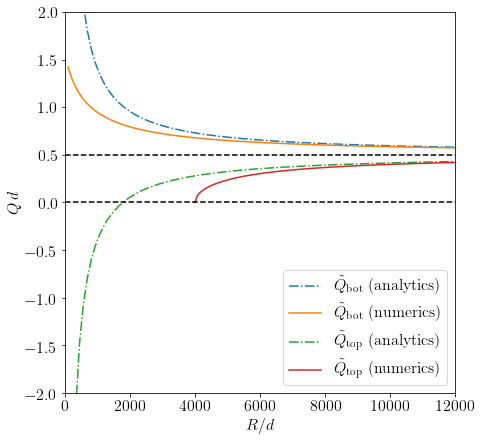

In [29]:
plt.figure(figsize=(7,7))
plt.plot(Rs_bot,Q_bot_an(Rs_bot,L),label='$\\tilde{Q}_\mathrm{bot}$ (analytics)', ls='-.')
plt.plot(Rs_bot,Q_bot(Rs_bot,L),label='$\\tilde{Q}_\mathrm{bot}$ (numerics)')
plt.plot(Rs_bot,Q_top_an(Rs_bot,L),label='$\\tilde{Q}_\mathrm{top}$ (analytics)', ls='-.')
plt.plot(Rs_top,Q_top(Rs_top,L),label='$\\tilde{Q}_\mathrm{top}$ (numerics)')
plt.axhline(0.0,ls='--', c='k')
plt.axhline(sqrt(t1),ls='--', c='k')
plt.ylabel('$Q\,d$')
plt.xlabel('$R/d$')
plt.ylim(-2,2)
plt.xlim(0.0,3*R_crit)
plt.legend(loc=4)
#plt.savefig('nodal_radius.pdf')

### (b) as a function of L

In [30]:
Ls_top = np.linspace(0,L_crit,101)
Ls_bot = np.linspace(0,3*L_crit,101)

In [31]:
L_crit

2000.0

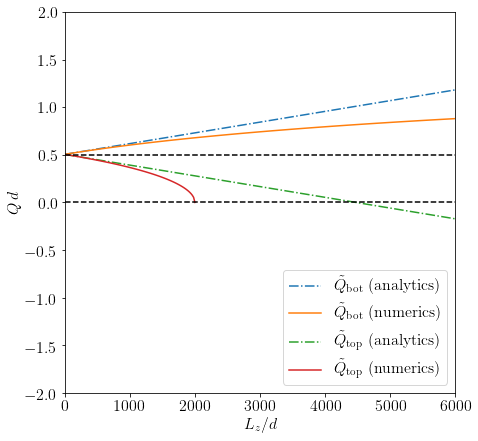

In [32]:
plt.figure(figsize=(7,7))
plt.plot(Ls_bot,Q_bot_an(R,Ls_bot),label='$\\tilde{Q}_\mathrm{bot}$ (analytics)', ls='-.')
plt.plot(Ls_bot,Q_bot(R,Ls_bot),label='$\\tilde{Q}_\mathrm{bot}$ (numerics)')
plt.plot(Ls_bot,Q_top_an(R,Ls_bot),label='$\\tilde{Q}_\mathrm{top}$ (analytics)', ls='-.')
plt.plot(Ls_top,Q_top(R,Ls_top),label='$\\tilde{Q}_\mathrm{top}$ (numerics)')
plt.axhline(0.0,ls='--', c='k')
plt.axhline(sqrt(t1),ls='--', c='k')
plt.ylabel('$Q\,d$')
plt.xlabel('$L_z/d$')
plt.ylim(-2,2)
plt.xlim(0.0,3*L_crit)
plt.legend(loc=4)
#plt.savefig('nodal_radius.pdf')

### Landau level spacing

(0.0, 0.1)

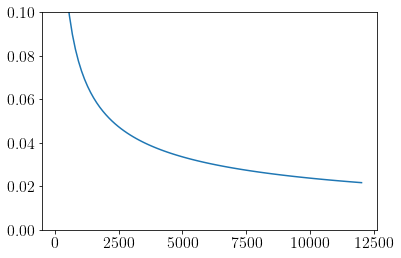

In [33]:
plt.plot(Rs_bot,sqrt(8*t2*cos(Qx)/Rs_bot))
plt.ylim(0.,0.1)